In [1]:
import pandas as pd
import numpy as np
import os
print(os.getcwd())

C:\Users\acer\zidio_6.2_foresight


In [2]:
calendar_df = pd.read_csv("calendar.csv")
sku_df = pd.read_csv("sku_master.csv")
inventory_df = pd.read_csv("inventory_snapshots.csv")
sales_df = pd.read_csv("sales_daily.csv")

In [3]:
print(calendar_df.shape)
calendar_df.head()

(731, 11)


,date,year,month,quarter,week,day_of_week,is_weekend,season,holiday,is_holiday,promotion_event
0,2024-01-01,2024,1,Q1,1,Monday,0,Winter,NaN,0,NaN
1,2024-01-02,2024,1,Q1,1,Tuesday,0,Winter,NaN,0,NaN
2,2024-01-03,2024,1,Q1,1,Wednesday,0,Winter,NaN,0,NaN
3,2024-01-04,2024,1,Q1,1,Thursday,0,Winter,NaN,0,NaN
4,2024-01-05,2024,1,Q1,1,Friday,0,Winter,NaN,0,NaN


In [4]:
print(sku_df.shape)
sku_df.head()

(50, 8)


,SKU,Product_Name,Category,Subcategory,Launch_Date,Cost_Price,Selling_Price,Gross_Margin_Per_Unit
0,SKU001,Product 001,Furniture,Chair,2022-04-09,1758.45,3664.05,1905.60
1,SKU002,Product 002,Home Decor,Table,2024-05-01,3867.09,3805.69,-61.40
2,SKU003,Product 003,Kitchen,Cushion,2023-12-22,589.48,8078.23,7488.75
3,SKU004,Product 004,Lighting,Cookware,2023-04-28,1445.74,6861.57,5415.83
4,SKU005,Product 005,Storage,Lamp,2023-04-22,5543.63,9493.22,3949.59


In [5]:
print(inventory_df.shape)
inventory_df.head()

(4800, 8)


,Snapshot_Date,SKU,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
0,2024-01-01,SKU001,16,23,11,7,18,58420.96
1,2024-01-01,SKU002,29,12,4,5,10,163983.40
2,2024-01-01,SKU003,34,23,14,6,20,209060.22
3,2024-01-01,SKU004,34,4,7,5,12,42257.92
4,2024-01-01,SKU005,23,5,5,6,11,170945.89


In [6]:
print(sales_df.shape)
sales_df.head()

(36550, 6)


,Date,SKU,Units_Sold,Revenue,Price,Promotion
0,2024-01-01,SKU001,5,18320.25,3664.05,0
1,2024-01-01,SKU002,15,57085.35,3805.69,0
2,2024-01-01,SKU003,5,40391.15,8078.23,0
3,2024-01-01,SKU004,5,34307.85,6861.57,0
4,2024-01-01,SKU005,12,113918.64,9493.22,0


In [7]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36550 entries, 0 to 36549
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        36550 non-null  object 
 1   SKU         36550 non-null  object 
 2   Units_Sold  36550 non-null  int64  
 3   Revenue     36550 non-null  float64
 4   Price       36550 non-null  float64
 5   Promotion   36550 non-null  int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 1.7+ MB


In [8]:
sales_df.isnull().sum()

Date          0
SKU           0
Units_Sold    0
Revenue       0
Price         0
Promotion     0
dtype: int64

In [9]:
sales_df.duplicated().sum()

np.int64(0)

In [10]:
print("Negative units:",(sales_df["Units_Sold"]<0).sum())
print("zero units:", (sales_df["Units_Sold"] ==0).sum())
print("Negative revenue:", (sales_df["Revenue"]<0).sum())

Negative units: 0
zero units: 202
Negative revenue: 0


In [11]:
sales_df["Date"] = pd.to_datetime(sales_df["Date"])
sales_df.info

<bound method DataFrame.info of             Date     SKU  Units_Sold    Revenue    Price  Promotion
0     2024-01-01  SKU001           5   18320.25  3664.05          0
1     2024-01-01  SKU002          15   57085.35  3805.69          0
2     2024-01-01  SKU003           5   40391.15  8078.23          0
3     2024-01-01  SKU004           5   34307.85  6861.57          0
4     2024-01-01  SKU005          12  113918.64  9493.22          0
...          ...     ...         ...        ...      ...        ...
36545 2025-12-31  SKU046           5   35877.70  7175.54          0
36546 2025-12-31  SKU047           6   47629.32  7938.22          0
36547 2025-12-31  SKU048           7    9656.85  1379.55          0
36548 2025-12-31  SKU049          16   83573.92  5223.37          0
36549 2025-12-31  SKU050           9    7944.48   882.72          0

[36550 rows x 6 columns]>

In [12]:
sales_df.dtypes

Date          datetime64[ns]
SKU                   object
Units_Sold             int64
Revenue              float64
Price                float64
Promotion              int64
dtype: object

In [13]:
print(sales_df['Date'].min(), sales_df['Date'].max())
print(sales_df['SKU'].nunique())

2024-01-01 00:00:00 2025-12-31 00:00:00
50


In [14]:
sku_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SKU                    50 non-null     object 
 1   Product_Name           50 non-null     object 
 2   Category               50 non-null     object 
 3   Subcategory            50 non-null     object 
 4   Launch_Date            50 non-null     object 
 5   Cost_Price             50 non-null     float64
 6   Selling_Price          50 non-null     float64
 7   Gross_Margin_Per_Unit  50 non-null     float64
dtypes: float64(3), object(5)
memory usage: 3.3+ KB


In [15]:
sku_df["Launch_Date"] = pd.to_datetime(sku_df["Launch_Date"])

In [16]:
sku_df.dtypes

SKU                              object
Product_Name                     object
Category                         object
Subcategory                      object
Launch_Date              datetime64[ns]
Cost_Price                      float64
Selling_Price                   float64
Gross_Margin_Per_Unit           float64
dtype: object

In [17]:
sku_df.isnull().sum()

SKU                      0
Product_Name             0
Category                 0
Subcategory              0
Launch_Date              0
Cost_Price               0
Selling_Price            0
Gross_Margin_Per_Unit    0
dtype: int64

In [18]:
sku_df.duplicated().sum()

np.int64(0)

In [19]:
sku_df['SKU'].duplicated().sum()

np.int64(0)

In [20]:
sku_df["Subcategory"].unique()

array(['Chair', 'Table', 'Cushion', 'Cookware', 'Lamp', 'Shelf',
       'Cabinet', 'Rug', 'Organizer', 'Sofa'], dtype=object)

In [21]:
sku_df["Category"].unique()


array(['Furniture', 'Home Decor', 'Kitchen', 'Lighting', 'Storage'],
      dtype=object)

In [22]:
calendar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             731 non-null    object
 1   year             731 non-null    int64 
 2   month            731 non-null    int64 
 3   quarter          731 non-null    object
 4   week             731 non-null    int64 
 5   day_of_week      731 non-null    object
 6   is_weekend       731 non-null    int64 
 7   season           731 non-null    object
 8   holiday          8 non-null      object
 9   is_holiday       731 non-null    int64 
 10  promotion_event  75 non-null     object
dtypes: int64(5), object(6)
memory usage: 62.9+ KB


In [23]:
calendar_df.isnull().sum()

date                 0
year                 0
month                0
quarter              0
week                 0
day_of_week          0
is_weekend           0
season               0
holiday            723
is_holiday           0
promotion_event    656
dtype: int64

In [24]:
calendar_df.duplicated().sum()

np.int64(0)

In [25]:
calendar_df["date"] = pd.to_datetime(calendar_df["date"])
print(calendar_df["date"].min(), calendar_df["date"].max())
print(calendar_df["date"].nunique())


2024-01-01 00:00:00 2025-12-31 00:00:00
731


In [26]:
inventory_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Snapshot_Date    4800 non-null   object 
 1   SKU              4800 non-null   object 
 2   Current_Stock    4800 non-null   int64  
 3   On_Order         4800 non-null   int64  
 4   Lead_Time_Days   4800 non-null   int64  
 5   Safety_Stock     4800 non-null   int64  
 6   Reorder_Point    4800 non-null   int64  
 7   Inventory_Value  4800 non-null   float64
dtypes: float64(1), int64(5), object(2)
memory usage: 300.1+ KB


In [27]:
inventory_df["Snapshot_Date"] = pd.to_datetime(inventory_df["Snapshot_Date"])
print(inventory_df["Snapshot_Date"].min(), inventory_df["Snapshot_Date"].max())
print(inventory_df["Snapshot_Date"].nunique())

2024-01-01 00:00:00 2025-12-01 00:00:00
24


In [28]:
inventory_df.dtypes

Snapshot_Date      datetime64[ns]
SKU                        object
Current_Stock               int64
On_Order                    int64
Lead_Time_Days              int64
Safety_Stock                int64
Reorder_Point               int64
Inventory_Value           float64
dtype: object

In [29]:
inventory_df.isnull().sum()

Snapshot_Date      0
SKU                0
Current_Stock      0
On_Order           0
Lead_Time_Days     0
Safety_Stock       0
Reorder_Point      0
Inventory_Value    0
dtype: int64

In [30]:
inventory_df.duplicated().sum()

np.int64(0)

In [31]:
print(inventory_df["SKU"].nunique())
print(inventory_df["Snapshot_Date"].nunique())

200
24


In [32]:
core_skus = set(sku_df['SKU'].unique())

inventory_core = inventory_df[inventory_df['SKU'].isin(core_skus)].copy()
inventory_extra = inventory_df[~inventory_df['SKU'].isin(core_skus)].copy()

print("Core inventory (matches sku_master):", inventory_core.shape, "-", inventory_core['SKU'].nunique(), "SKUs")
print("Extra inventory (no match):", inventory_extra.shape, "-", inventory_extra['SKU'].nunique(), "SKUs")

Core inventory (matches sku_master): (1200, 8) - 50 SKUs
Extra inventory (no match): (3600, 8) - 150 SKUs


In [33]:
print(sku_df.shape)

(50, 8)


In [34]:
sales_df.to_csv("sales_clean.csv", index=False)
sku_df.to_csv("sku_clean.csv", index=False)
calendar_df.to_csv("calendar_clean.csv", index=False)
inventory_core.to_csv("inventory_core_clean.csv", index=False)
inventory_extra.to_csv("inventory_extra_clean.csv", index=False)

print("All cleaned files saved.")

All cleaned files saved.


In [35]:
master_df = sales_df.merge(calendar_df, left_on="Date", right_on="date", how="left")
master_df = master_df.merge(sku_df, on="SKU", how="left")
master_df.drop(columns=["date"], inplace=True)

print(master_df.shape)
master_df.head()

(36550, 23)


,Date,SKU,Units_Sold,Revenue,Price,Promotion,year,month,quarter,week,...,holiday,is_holiday,promotion_event,Product_Name,Category,Subcategory,Launch_Date,Cost_Price,Selling_Price,Gross_Margin_Per_Unit
0,2024-01-01,SKU001,5,18320.25,3664.05,0,2024,1,Q1,1,...,NaN,0,NaN,Product 001,Furniture,Chair,2022-04-09,1758.45,3664.05,1905.60
1,2024-01-01,SKU002,15,57085.35,3805.69,0,2024,1,Q1,1,...,NaN,0,NaN,Product 002,Home Decor,Table,2024-05-01,3867.09,3805.69,-61.40
2,2024-01-01,SKU003,5,40391.15,8078.23,0,2024,1,Q1,1,...,NaN,0,NaN,Product 003,Kitchen,Cushion,2023-12-22,589.48,8078.23,7488.75
3,2024-01-01,SKU004,5,34307.85,6861.57,0,2024,1,Q1,1,...,NaN,0,NaN,Product 004,Lighting,Cookware,2023-04-28,1445.74,6861.57,5415.83
4,2024-01-01,SKU005,12,113918.64,9493.22,0,2024,1,Q1,1,...,NaN,0,NaN,Product 005,Storage,Lamp,2023-04-22,5543.63,9493.22,3949.59


In [36]:
master_df.isnull().sum()

Date                         0
SKU                          0
Units_Sold                   0
Revenue                      0
Price                        0
Promotion                    0
year                         0
month                        0
quarter                      0
week                         0
day_of_week                  0
is_weekend                   0
season                       0
holiday                  36150
is_holiday                   0
promotion_event          32800
Product_Name                 0
Category                     0
Subcategory                  0
Launch_Date                  0
Cost_Price                   0
Selling_Price                0
Gross_Margin_Per_Unit        0
dtype: int64

In [37]:
print(len(sales_df), len(master_df))

36550 36550


In [38]:
master_df["Days_Since_Launch"] = (master_df["Date"] - master_df["Launch_Date"]).dt.days
master_df["Gross_Revenue_Margin"] = (master_df["Price"]-master_df["Cost_Price"]) * master_df["Units_Sold"]

master_df.sort_values(["SKU" , "Date"], inplace=True)
master_df.reset_index(drop=True, inplace = True)

master_df[["Date", "SKU", "Days_Since_Launch", "Gross_Revenue_Margin"]].head()

,Date,SKU,Days_Since_Launch,Gross_Revenue_Margin
0,2024-01-01,SKU001,632,9528.0
1,2024-01-02,SKU001,633,24772.8
2,2024-01-03,SKU001,634,22867.2
3,2024-01-04,SKU001,635,43828.8
4,2024-01-05,SKU001,636,30489.6


In [39]:
master_df.to_csv("master_daily_clean.csv", index=False)
print("Saved master_daily_clean.csv:", master_df.shape)

Saved master_daily_clean.csv: (36550, 25)


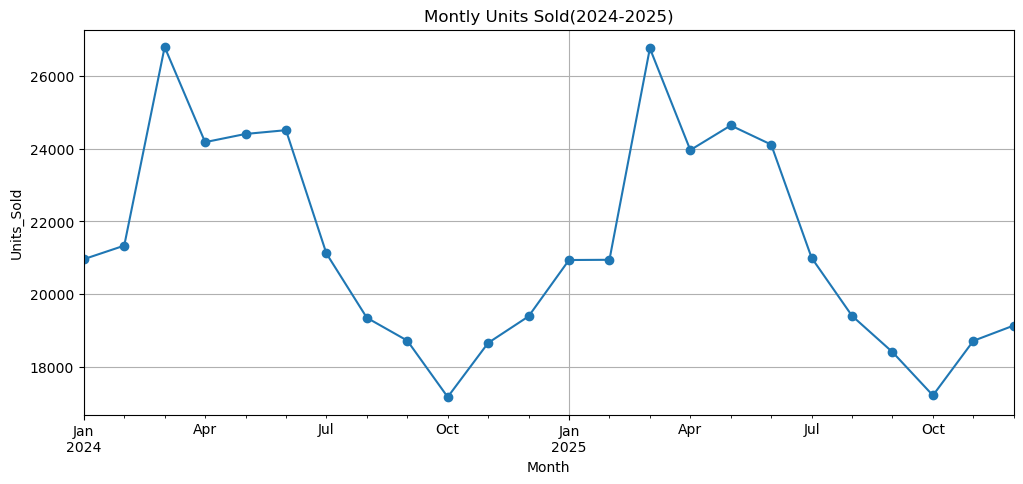

In [40]:
import matplotlib.pyplot as plt
monthly_sales = master_df.groupby(master_df["Date"].dt.to_period("M"))["Units_Sold"].sum()
plt.figure(figsize=(12,5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Montly Units Sold(2024-2025)")
plt.xlabel("Month")
plt.ylabel("Units_Sold")
plt.grid(True)
plt.show()

            Total_Units  Total_Revenue  SKU_Count
Category                                         
Home Decor       132570   8.884681e+08         10
Furniture         82298   6.033905e+08         10
Storage           93367   5.819274e+08         10
Kitchen          101144   5.635346e+08         10
Lighting         102431   4.587362e+08         10


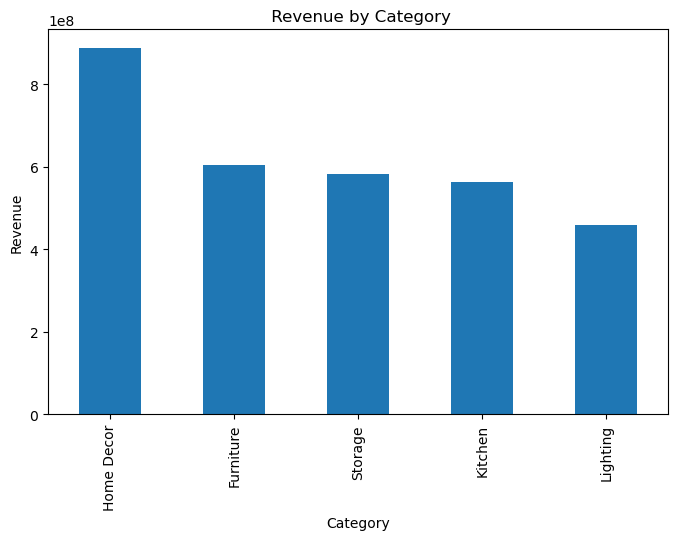

In [41]:
category_perf = master_df.groupby("Category").agg(
Total_Units =("Units_Sold", "sum"),
Total_Revenue =("Revenue","sum"),
SKU_Count= ("SKU", "nunique")
).sort_values("Total_Revenue", ascending=False)
print(category_perf)

category_perf["Total_Revenue"].plot(kind="bar", figsize =(8,5), title= " Revenue by Category")
plt.ylabel("Revenue")
plt.show()
    

In [42]:
promo_impact = master_df.groupby("Promotion")["Units_Sold"].mean()
print(promo_impact)

Promotion
0    13.475945
1    18.613067
Name: Units_Sold, dtype: float64


In [43]:
season_avg = master_df.groupby("season")["Units_Sold"].mean().sort_values(ascending = False)
print(season_avg)

season
Spring     16.669508
Summer     16.008852
Winter     13.558453
Monsoon    12.826196
Autumn     11.765082
Name: Units_Sold, dtype: float64


In [44]:
weekend_avg = master_df.groupby("is_weekend")["Units_Sold"].mean().sort_values(ascending = False)
print(weekend_avg)

is_weekend
1    16.329519
0    13.077744
Name: Units_Sold, dtype: float64


In [45]:
sku_revenue = master_df.groupby(['SKU','Product_Name'])['Revenue'].sum().sort_values(ascending=False)

print("Top 5 SKUs by revenue:")
print(sku_revenue.head(5))

print("\nBottom 5 SKUs by revenue:")
print(sku_revenue.tail(5))

Top 5 SKUs by revenue:
SKU     Product_Name
SKU026  Product 026     1.808853e+08
SKU035  Product 035     1.691619e+08
SKU012  Product 012     1.673962e+08
SKU042  Product 042     1.528478e+08
SKU027  Product 027     1.508886e+08
Name: Revenue, dtype: float64

Bottom 5 SKUs by revenue:
SKU     Product_Name
SKU028  Product 028     14288253.09
SKU048  Product 048      8518721.25
SKU010  Product 010      8267375.06
SKU050  Product 050      4004900.64
SKU011  Product 011      2818336.56
Name: Revenue, dtype: float64


In [46]:
holiday_avg = master_df.groupby('is_holiday')['Units_Sold'].mean()
print(holiday_avg)

is_holiday
0    14.023402
1    12.160000
Name: Units_Sold, dtype: float64


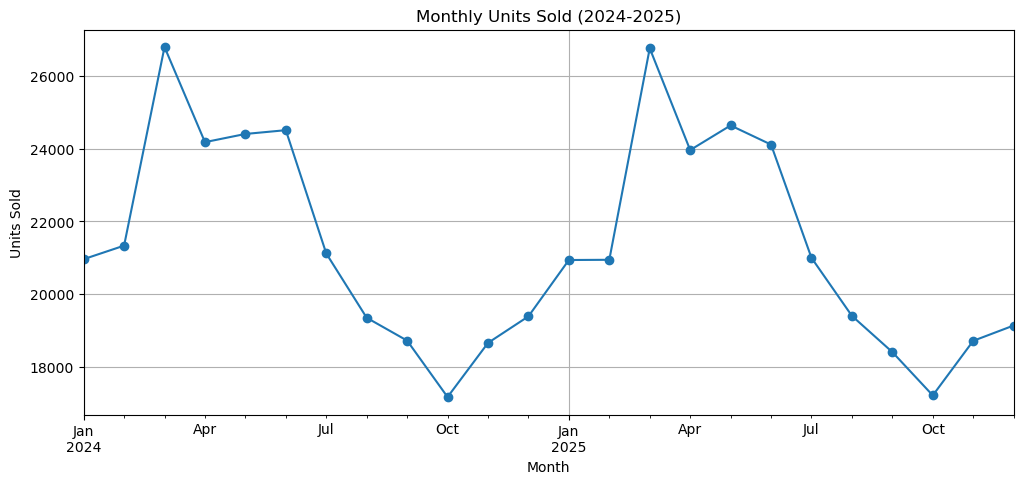

In [47]:
import matplotlib.pyplot as plt

monthly_sales = master_df.groupby(master_df['Date'].dt.to_period('M'))['Units_Sold'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Units Sold (2024-2025)')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.grid(True)
plt.show()

In [48]:
inventory_core['Snapshot_Date'] = pd.to_datetime(inventory_core['Snapshot_Date'])
latest_date = inventory_core['Snapshot_Date'].max()
latest_inv = inventory_core[inventory_core['Snapshot_Date'] == latest_date].copy()

latest_inv['Stock_vs_Reorder'] = latest_inv['Current_Stock'] - latest_inv['Reorder_Point']
below_reorder = (latest_inv['Stock_vs_Reorder'] < 0).sum()

print(f"Snapshot date: {latest_date.date()}")
print(f"SKUs below reorder point: {below_reorder} out of {len(latest_inv)}")
print(f"Average lead time: {latest_inv['Lead_Time_Days'].mean():.1f} days")

import os
os.chdir(r"C:\Users\acer\zidio_6.2_foresight")

Snapshot date: 2025-12-01
SKUs below reorder point: 14 out of 50
Average lead time: 7.8 days


In [49]:
master_df = master_df.sort_values(['SKU', 'Date']).reset_index(drop=True)

In [50]:
master_df['Lag_1'] = master_df.groupby('SKU')['Units_Sold'].shift(1)
master_df['Lag_7'] = master_df.groupby('SKU')['Units_Sold'].shift(7)
master_df['Lag_14'] = master_df.groupby('SKU')['Units_Sold'].shift(14)

master_df[['SKU','Date','Units_Sold','Lag_1','Lag_7','Lag_14']].head(10)

,SKU,Date,Units_Sold,Lag_1,Lag_7,Lag_14
0,SKU001,2024-01-01,5,NaN,NaN,NaN
1,SKU001,2024-01-02,13,5.0,NaN,NaN
2,SKU001,2024-01-03,12,13.0,NaN,NaN
3,SKU001,2024-01-04,23,12.0,NaN,NaN
4,SKU001,2024-01-05,16,23.0,NaN,NaN
5,SKU001,2024-01-06,18,16.0,NaN,NaN
6,SKU001,2024-01-07,19,18.0,NaN,NaN
7,SKU001,2024-01-08,12,19.0,5.0,NaN
8,SKU001,2024-01-09,10,12.0,13.0,NaN
9,SKU001,2024-01-10,11,10.0,12.0,NaN


In [51]:
master_df['Rolling_7'] = master_df.groupby('SKU')['Units_Sold'].transform(lambda x: x.rolling(7).mean())
master_df['Rolling_30'] = master_df.groupby('SKU')['Units_Sold'].transform(lambda x: x.rolling(30).mean())

master_df[['SKU','Date','Units_Sold','Rolling_7','Rolling_30']].head(10)

,SKU,Date,Units_Sold,Rolling_7,Rolling_30
0,SKU001,2024-01-01,5,NaN,NaN
1,SKU001,2024-01-02,13,NaN,NaN
2,SKU001,2024-01-03,12,NaN,NaN
3,SKU001,2024-01-04,23,NaN,NaN
4,SKU001,2024-01-05,16,NaN,NaN
5,SKU001,2024-01-06,18,NaN,NaN
6,SKU001,2024-01-07,19,15.142857,NaN
7,SKU001,2024-01-08,12,16.142857,NaN
8,SKU001,2024-01-09,10,15.714286,NaN
9,SKU001,2024-01-10,11,15.571429,NaN


In [52]:
print(master_df[['Lag_1','Lag_7','Lag_14','Rolling_7','Rolling_30']].isnull().sum())

Lag_1           50
Lag_7          350
Lag_14         700
Rolling_7      300
Rolling_30    1450
dtype: int64


In [53]:
master_df_features = master_df.dropna(subset=['Lag_1','Lag_7','Lag_14','Rolling_7','Rolling_30']).reset_index(drop=True)

print("Before:", master_df.shape)
print("After:", master_df_features.shape)

Before: (36550, 30)
After: (35100, 30)


In [54]:
master_df_features = pd.get_dummies(master_df_features, columns=['Category', 'season'], drop_first=True)

master_df_features.columns.tolist()

['Date',
 'SKU',
 'Units_Sold',
 'Revenue',
 'Price',
 'Promotion',
 'year',
 'month',
 'quarter',
 'week',
 'day_of_week',
 'is_weekend',
 'holiday',
 'is_holiday',
 'promotion_event',
 'Product_Name',
 'Subcategory',
 'Launch_Date',
 'Cost_Price',
 'Selling_Price',
 'Gross_Margin_Per_Unit',
 'Days_Since_Launch',
 'Gross_Revenue_Margin',
 'Lag_1',
 'Lag_7',
 'Lag_14',
 'Rolling_7',
 'Rolling_30',
 'Category_Home Decor',
 'Category_Kitchen',
 'Category_Lighting',
 'Category_Storage',
 'season_Monsoon',
 'season_Spring',
 'season_Summer',
 'season_Winter']

In [55]:
master_df_features[['SKU','Category_Home Decor','Category_Kitchen','Category_Lighting','Category_Storage']].drop_duplicates(subset='SKU').head(10)

,SKU,Category_Home Decor,Category_Kitchen,Category_Lighting,Category_Storage
0,SKU001,False,False,False,False
702,SKU002,True,False,False,False
1404,SKU003,False,True,False,False
2106,SKU004,False,False,True,False
2808,SKU005,False,False,False,True
3510,SKU006,False,False,False,False
4212,SKU007,True,False,False,False
4914,SKU008,False,True,False,False
5616,SKU009,False,False,True,False
6318,SKU010,False,False,False,True


In [56]:
master_df_features.to_csv("master_features.csv", index=False)
print("Saved:", master_df_features.shape)

Saved: (35100, 36)


In [57]:
split_date = master_df_features['Date'].max() - pd.Timedelta(days=60)
print("Split date:", split_date)

train = master_df_features[master_df_features['Date'] <= split_date]
test = master_df_features[master_df_features['Date'] > split_date]

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train date range:", train['Date'].min(), "to", train['Date'].max())
print("Test date range:", test['Date'].min(), "to", test['Date'].max())

Split date: 2025-11-01 00:00:00
Train shape: (32100, 36)
Test shape: (3000, 36)
Train date range: 2024-01-30 00:00:00 to 2025-11-01 00:00:00
Test date range: 2025-11-02 00:00:00 to 2025-12-31 00:00:00


In [58]:
drop_cols = ['Date', 'SKU', 'Units_Sold', 'Revenue', 'Product_Name', 'Subcategory', 
             'Launch_Date', 'holiday', 'promotion_event']
feature_cols = [c for c in master_df_features.columns if c not in drop_cols]
X_train = train[feature_cols]
y_train = train['Units_Sold']
X_test = test[feature_cols]
y_test = test['Units_Sold']

print("Features used:", feature_cols)
print("X_train:", X_train.shape, "y_train:", y_train.shape)

Features used: ['Price', 'Promotion', 'year', 'month', 'quarter', 'week', 'day_of_week', 'is_weekend', 'is_holiday', 'Cost_Price', 'Selling_Price', 'Gross_Margin_Per_Unit', 'Days_Since_Launch', 'Gross_Revenue_Margin', 'Lag_1', 'Lag_7', 'Lag_14', 'Rolling_7', 'Rolling_30', 'Category_Home Decor', 'Category_Kitchen', 'Category_Lighting', 'Category_Storage', 'season_Monsoon', 'season_Spring', 'season_Summer', 'season_Winter']
X_train: (32100, 27) y_train: (32100,)


In [59]:

drop_cols = ['Date', 'SKU', 'Units_Sold', 'Revenue', 'Gross_Revenue_Margin', 'Product_Name', 
             'Subcategory', 'Launch_Date', 'holiday', 'promotion_event']
master_df_features = pd.get_dummies(master_df_features, columns=['quarter', 'day_of_week'], drop_first=True)
train = master_df_features[master_df_features['Date'] <= split_date]
test = master_df_features[master_df_features['Date'] > split_date]

feature_cols = [c for c in master_df_features.columns if c not in drop_cols]

X_train = train[feature_cols]
y_train = train['Units_Sold']
X_test = test[feature_cols]
y_test = test['Units_Sold']

print("Features used:", feature_cols)
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("\nData types check:")
print(X_train.dtypes.value_counts())

Features used: ['Price', 'Promotion', 'year', 'month', 'week', 'is_weekend', 'is_holiday', 'Cost_Price', 'Selling_Price', 'Gross_Margin_Per_Unit', 'Days_Since_Launch', 'Lag_1', 'Lag_7', 'Lag_14', 'Rolling_7', 'Rolling_30', 'Category_Home Decor', 'Category_Kitchen', 'Category_Lighting', 'Category_Storage', 'season_Monsoon', 'season_Spring', 'season_Summer', 'season_Winter', 'quarter_Q2', 'quarter_Q3', 'quarter_Q4', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday']
X_train: (32100, 33) y_train: (32100,)

Data types check:
bool       17
float64     9
int64       7
Name: count, dtype: int64


In [60]:
!pip install xgboost --quiet

In [61]:
from xgboost import XGBRegressor
model =XGBRegressor(
n_estimators = 300,
max_depth = 6,
learning_rate = 0.05,
random_state = 42
)
model.fit(X_train, y_train)
print("model trained.")

model trained.


In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test.replace(0, np.nan))) * 100

print(f"MAE  (Mean Absolute Error): {mae:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error): {mape:.2f}%")

MAE  (Mean Absolute Error): 2.50
RMSE (Root Mean Squared Error): 3.23
MAPE (Mean Absolute % Error): 30.01%


In [63]:
results= test[["SKU", "Date"]].copy()
results["Actual"] = y_test.values
results["Predicted"] = y_pred
results["Abs_Error"] = abs(results["Actual"] - results["Predicted"])
results["APE"] = results["Abs_Error"]/ results["Actual"].replace(0,np.nan)*100
sku_accuracy = results.groupby("SKU").agg(
    Avg_Actual = ("Actual", "mean"),
    Avg_Predicted = ("Predicted", "mean"),
    MAPE = ("APE", "mean")
).sort_values("MAPE")

print("Best Predicted SKUs:")
print(sku_accuracy.head(5))
print("worst Predicted SKUs:")
print(sku_accuracy.tail(5))

Best Predicted SKUs:
        Avg_Actual  Avg_Predicted       MAPE
SKU                                         
SKU037   21.666667      21.882698  14.791388
SKU027   22.466667      22.497181  16.026006
SKU042   20.366667      20.703115  16.039590
SKU018   22.283333      22.615728  17.236820
SKU043   19.666667      19.577209  17.485346
worst Predicted SKUs:
        Avg_Actual  Avg_Predicted       MAPE
SKU                                         
SKU028    4.616667       4.730606  50.235985
SKU011    2.550000       2.579594  52.918473
SKU003    5.016667       5.020658  57.060253
SKU015    3.400000       3.412531  57.985649
SKU039    2.650000       2.651287  62.750737


In [64]:
import joblib
joblib.dump(model, "demand_forecast_model.pkl")

results.to_csv("forecast_results.csv", index=False)
sku_accuracy.to_csv("sku_accuracy.csv", index=False)

print("Model and results saved.")

Model and results saved.


In [65]:
latest_date = inventory_core["Snapshot_Date"].max()
latest_inv = inventory_core[inventory_core["Snapshot_Date"] == latest_date].copy()
print("Snapshot date:", latest_date)
latest_inv.head()

Snapshot date: 2025-12-01 00:00:00


,Snapshot_Date,SKU,Current_Stock,On_Order,Lead_Time_Days,Safety_Stock,Reorder_Point,Inventory_Value
4600,2025-12-01,SKU001,771,147,4,159,289,2815160.01
4601,2025-12-01,SKU002,526,29,3,94,149,2974319.60
4602,2025-12-01,SKU003,349,12,3,88,123,2145941.67
4603,2025-12-01,SKU004,259,254,6,98,196,321905.92
4604,2025-12-01,SKU005,471,291,6,129,245,3500674.53


In [66]:
recent_window = master_df_features['Date'].max() - pd.Timedelta(days=30)
recent_sales = master_df_features[master_df_features['Date'] > recent_window]

avg_daily_demand = recent_sales.groupby('SKU')['Units_Sold'].mean().reset_index()
avg_daily_demand.columns = ['SKU', 'Avg_Daily_Demand']

avg_daily_demand.head()

,SKU,Avg_Daily_Demand
0,SKU001,12.333333
1,SKU002,7.633333
2,SKU003,4.666667
3,SKU004,4.533333
4,SKU005,14.600000


In [67]:
risk_df = latest_inv.merge(avg_daily_demand, on="SKU", how="left")

risk_df["Days_of_Stock_Left"] = risk_df["Current_Stock"] / risk_df["Avg_Daily_Demand"]
risk_df["Stock_vs_Reorder"] = risk_df["Current_Stock"] - risk_df["Reorder_Point"]

risk_df[['SKU','Current_Stock','Avg_Daily_Demand','Days_of_Stock_Left','Lead_Time_Days','Reorder_Point','Stock_vs_Reorder']].head(10)

,SKU,Current_Stock,Avg_Daily_Demand,Days_of_Stock_Left,Lead_Time_Days,Reorder_Point,Stock_vs_Reorder
0,SKU001,771,12.333333,62.513514,4,289,482
1,SKU002,526,7.633333,68.908297,3,149,377
2,SKU003,349,4.666667,74.785714,3,123,226
3,SKU004,259,4.533333,57.132353,6,196,63
4,SKU005,471,14.600000,32.260274,6,245,226
5,SKU006,359,5.900000,60.847458,13,340,19
6,SKU007,207,21.566667,9.598145,8,237,-30
7,SKU008,325,14.366667,22.621810,3,161,164
8,SKU009,75,10.600000,7.075472,7,131,-56
9,SKU010,83,15.933333,5.209205,13,60,23


In [ ]:
print(risk_df.columns.tolist())

In [71]:
def classify_risk(row):
    if row['Days_of_Stock_Left'] <= row['Lead_Time_Days']:
        return 'High Risk - Stockout Likely'
    elif row['Stock_vs_Reorder'] < 0:
        return 'Medium Risk - Below Reorder Point'
    elif row['Days_of_Stock_Left'] > 60:
        return 'Overstock Risk'
    else:
        return 'Healthy'
risk_df['Risk_Level'] = risk_df.apply(classify_risk, axis=1)
risk_df['Risk_Level'].value_counts()

Risk_Level
Healthy                              26
Overstock Risk                        8
Medium Risk - Below Reorder Point     8
High Risk - Stockout Likely           8
Name: count, dtype: int64

In [72]:
high_risk = risk_df[risk_df['Risk_Level'] == 'High Risk - Stockout Likely'][
    ['SKU','Current_Stock','Avg_Daily_Demand','Days_of_Stock_Left','Lead_Time_Days']
].sort_values('Days_of_Stock_Left')

print(high_risk)

       SKU  Current_Stock  Avg_Daily_Demand  Days_of_Stock_Left  \
33  SKU034             34         17.766667            1.913696   
11  SKU012             47         23.033333            2.040521   
41  SKU042             90         21.266667            4.231975   
39  SKU040             67         13.033333            5.140665   
9   SKU010             83         15.933333            5.209205   
30  SKU031             93         15.600000            5.961538   
16  SKU017             95         13.300000            7.142857   
22  SKU023            130         13.933333            9.330144   

    Lead_Time_Days  
33               5  
11              12  
41               6  
39               9  
9               13  
30              13  
16              12  
22              12  


KeyError: 'Risk_Level'

In [73]:
risk_df.to_csv("risk_scoring_output.csv", index=False)
print("Saved:", risk_df.shape)

Saved: (50, 12)


In [69]:

risk_df = risk_df.merge(sku_df[['SKU', 'Cost_Price', 'Selling_Price']], on='SKU', how='left')
shortfall_days = (risk_df['Lead_Time_Days'] - risk_df['Days_of_Stock_Left']).clip(lower=0)
risk_df['Sales_At_Risk_INR'] = np.where(
    risk_df['Risk_Level'] == 'High Risk - Stockout Likely',
    shortfall_days * risk_df['Avg_Daily_Demand'] * risk_df['Selling_Price'],
    0
)

# --- Capital locked (for Overstock SKUs): value of stock beyond a healthy 60-day supply ---
healthy_stock_level = 60 * risk_df['Avg_Daily_Demand']
excess_units = (risk_df['Current_Stock'] - healthy_stock_level).clip(lower=0)
risk_df['Capital_Locked_INR'] = np.where(
    risk_df['Risk_Level'] == 'Overstock Risk',
    excess_units * risk_df['Cost_Price'],
    0
)

print("Total sales at risk: ₹", round(risk_df['Sales_At_Risk_INR'].sum()))
print("Total capital locked: ₹", round(risk_df['Capital_Locked_INR'].sum()))

risk_df.to_csv("risk_scoring_output.csv", index=False)
print("Saved with rupee columns.")

KeyError: 'Risk_Level'

In [70]:
print(risk_df.columns.tolist())


['Snapshot_Date', 'SKU', 'Current_Stock', 'On_Order', 'Lead_Time_Days', 'Safety_Stock', 'Reorder_Point', 'Inventory_Value', 'Avg_Daily_Demand', 'Days_of_Stock_Left', 'Stock_vs_Reorder', 'Cost_Price_x', 'Selling_Price_x', 'Cost_Price_y', 'Selling_Price_y']


In [72]:

risk_df['Cost_Price'] = risk_df['Cost_Price_x']
risk_df['Selling_Price'] = risk_df['Selling_Price_x']
risk_df = risk_df.drop(columns=['Cost_Price_x', 'Cost_Price_y', 'Selling_Price_x', 'Selling_Price_y'])

def classify_risk(row):
    if row['Days_of_Stock_Left'] <= row['Lead_Time_Days']:
        return 'High Risk - Stockout Likely'
    elif row['Stock_vs_Reorder'] < 0:
        return 'Medium Risk - Below Reorder Point'
    elif row['Days_of_Stock_Left'] > 60:
        return 'Overstock Risk'
    else:
        return 'Healthy'

risk_df['Risk_Level'] = risk_df.apply(classify_risk, axis=1)


shortfall_days = (risk_df['Lead_Time_Days'] - risk_df['Days_of_Stock_Left']).clip(lower=0)
risk_df['Sales_At_Risk_INR'] = np.where(
    risk_df['Risk_Level'] == 'High Risk - Stockout Likely',
    shortfall_days * risk_df['Avg_Daily_Demand'] * risk_df['Selling_Price'],
    0
)

healthy_stock_level = 60 * risk_df['Avg_Daily_Demand']
excess_units = (risk_df['Current_Stock'] - healthy_stock_level).clip(lower=0)
risk_df['Capital_Locked_INR'] = np.where(
    risk_df['Risk_Level'] == 'Overstock Risk',
    excess_units * risk_df['Cost_Price'],
    0
)

print("Total sales at risk: ₹", round(risk_df['Sales_At_Risk_INR'].sum()))
print("Total capital locked: ₹", round(risk_df['Capital_Locked_INR'].sum()))
print("\nColumns:", risk_df.columns.tolist())

risk_df.to_csv("risk_scoring_output.csv", index=False)
print("Saved.")

KeyError: 'Cost_Price_x'

In [73]:
print(risk_df.columns.tolist())


['Snapshot_Date', 'SKU', 'Current_Stock', 'On_Order', 'Lead_Time_Days', 'Safety_Stock', 'Reorder_Point', 'Inventory_Value', 'Avg_Daily_Demand', 'Days_of_Stock_Left', 'Stock_vs_Reorder', 'Cost_Price', 'Selling_Price', 'Risk_Level', 'Sales_At_Risk_INR', 'Capital_Locked_INR']


In [74]:
print("Total sales at risk: ₹", round(risk_df['Sales_At_Risk_INR'].sum()))
print("Total capital locked: ₹", round(risk_df['Capital_Locked_INR'].sum()))

risk_df.to_csv("risk_scoring_output.csv", index=False)
print("Saved.")

Total sales at risk: ₹ 4206076
Total capital locked: ₹ 5080982
Saved.
